In [8]:
import warnings
warnings.filterwarnings("ignore")

from flonacomldft.utils.io_utils import (
    get_path,
    load_pickle_file,
)

from flonacomldft.utils.diagnostics import avg_windows

import seaborn as sns
import torch
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

size=18
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

## DFT Adaptive sampling simulations

In [224]:
path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
ids_is0 = [25072550, 25128620, 25222540, 25222570]
ids_is1 = [25072551, 25128621, 25222541, 25222571, 25320981]

In [225]:
get_adaptive_simulation = lambda isomer, number_id, path: load_pickle_file("results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(isomer, number_id, isomer, number_id), path)

In [226]:
adaptive_is0 = [get_adaptive_simulation(0, ids_is0[i], path) for i in range(len(ids_is0))]
adaptive_is1 = [get_adaptive_simulation(1, ids_is1[i], path) for i in range(len(ids_is1))]

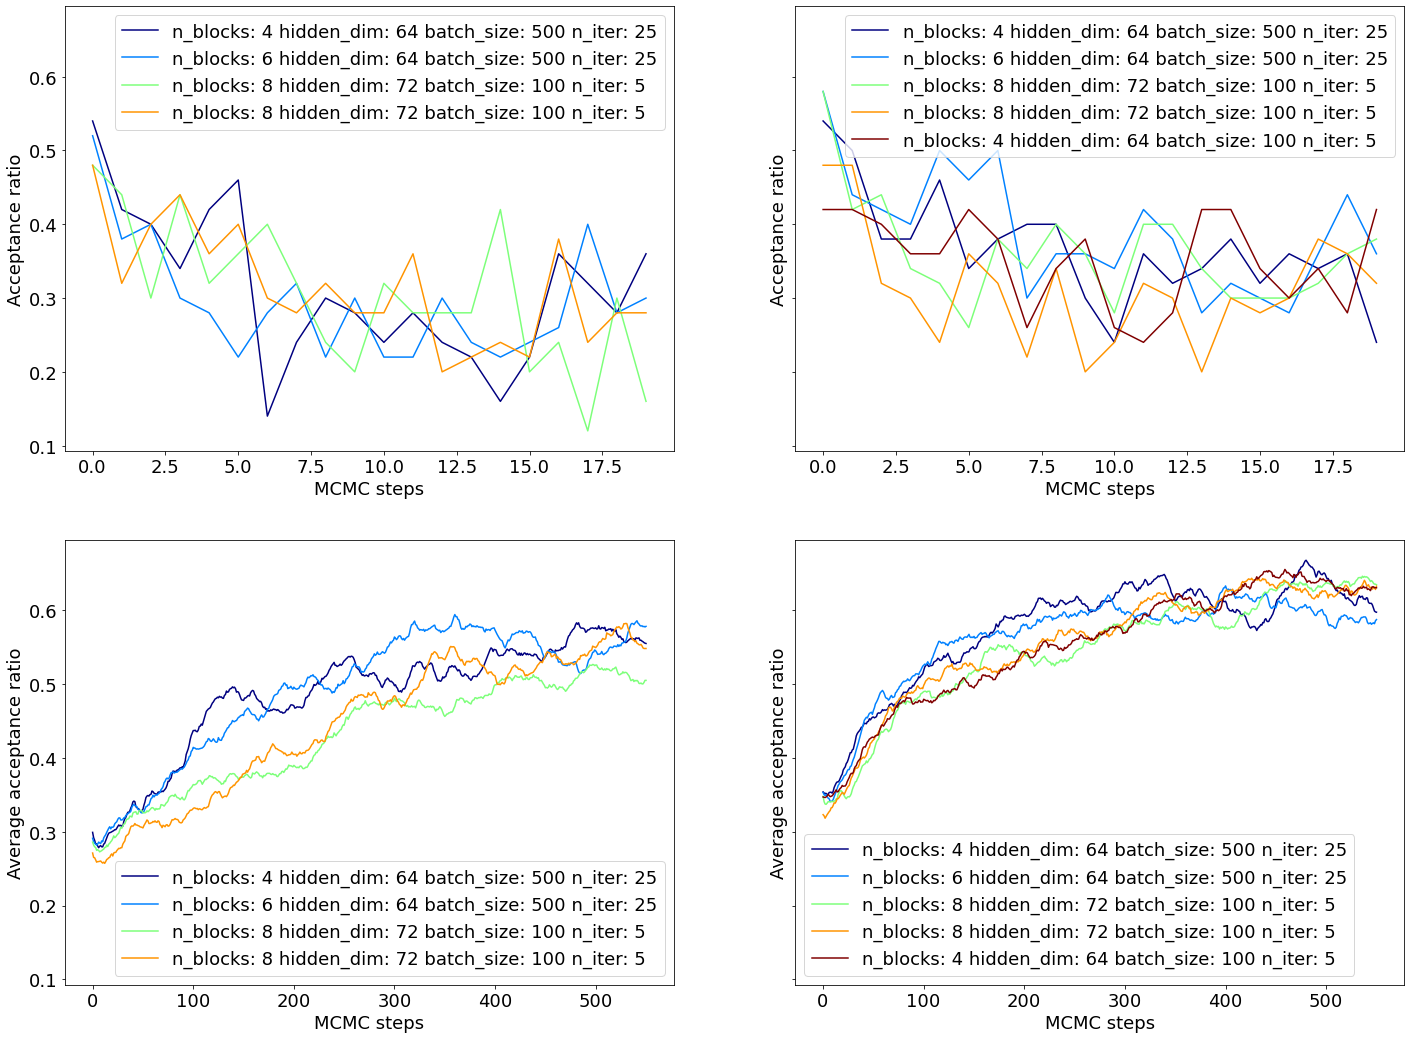

In [74]:
window = 50

all_simulation_accs = []

fig, axs = plt.subplots(2, 2, figsize=(24, 18), sharey=True)

color = cm.jet(np.linspace(0, 1, len(adaptive)))

for j, adaptive in enumerate([adaptive_is0, adaptive_is1]):

    for i in range(len(adaptive)):
    
        simulation_label = "n_blocks: "+str(adaptive[i]["args"]["n_blocks"])
        simulation_label = simulation_label + " hidden_dim: "+str(adaptive[i]["args"]["hidden_dim"])
        simulation_label = simulation_label + " batch_size: "+str(adaptive[i]["args"]["batch_size"])
        simulation_label = simulation_label + " n_iter: "+str(adaptive[i]["args"]["n_iter"])

        accs = torch.cat(adaptive[i]["accs"]).mean(dim=1)
        all_simulation_accs.append(accs.clone())

        axs[0][j].plot(accs[:adaptive[i]["args"]["n_steps"]], c=color[i], label=simulation_label)
    
        accs_avg = avg_windows(accs, window_size=window, axis=1)
    
        axs[1][j].plot(accs_avg, c=color[i], label=simulation_label)

    axs[0][j].set_xlabel("MCMC steps")
    axs[1][j].set_xlabel("MCMC steps")
    
    axs[0][j].set_ylabel("Acceptance ratio")
    axs[1][j].set_ylabel("Average acceptance ratio")
        
    axs[0][j].legend()
    axs[1][j].legend()

In [169]:
from ase.io import read
from ase.units import kB
from flonacomldft.internal_coordinates import Coordinates_mapping

def load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer=None):

    ag6_proposals = []
    for chain in range(n_chains):
        for step in range(n_steps):
            print("ag6_{:d}_{:d}_{:d}.out".format(n_run, step, chain))
            ag6_proposals.append(read("{:s}DFTAdaptive/ag6_{:d}_{:d}_{:d}.out".format(path, n_run, step, chain)))

    coord_mapping = Coordinates_mapping()

    zmat = coord_mapping.get_internal_from_trajectory(ag6_proposals, isomer=isomer, temperature=300)
    xs = coord_mapping.get_real_centered_from_internal(zmat[:, :12], isomer=isomer, energies=zmat[:, 12])        
    
    return xs, zmat, ag6_proposals

def get_participation_ratio_from_dft_proposals(xs, us, model, kB, T):
    
    n_prop = xs.shape[0]
    
    log_weight = -us.squeeze()/(kB*T) + model.nll(xs)
    log_ratio = torch.logsumexp(2 * log_weight, dim=0) - 2 * torch.logsumexp(log_weight, dim=0)
    
    return torch.exp(-log_ratio) / n_prop  

In [242]:
molecules_path = lambda isomer, number_id: "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2/results_adaptive_is{:d}_{:d}/".format(isomer, number_id)

In [228]:
ids_is0

[25072550, 25128620, 25222540, 25222570]

In [268]:
def compute_part_ratios_per_adaptive(adaptive, number_id, isomer):

    part_ratios = []

    n_runs = adaptive["args"]["n_runs"]
    n_chains = adaptive["args"]["n_runs"]
    n_steps = adaptive["args"]["n_steps"]

    for n_run in range(n_runs):
    
        model = adaptive["dict_flows_training"][n_run][0]['model']
        xs = load_proposal_from_flow(molecules_path(isomer, number_id), n_run, n_chains, n_steps, isomer)[0]

        part_ratio = get_participation_ratio_from_dft_proposals(xs[0].float(), xs[2].float(), model, kB, 300)
    
        part_ratios.append(part_ratio)
        
    mcmc_steps = list(range(0, n_runs*n_steps, n_steps))
        
    return part_ratios, mcmc_steps

In [269]:
part_ratios_is0, mcmc_steps_is0 = compute_part_ratios_per_adaptive(adaptive_is0[0], ids_is0[0], 0)

In [270]:
part_ratios_is1, mcmc_steps_is1 = compute_part_ratios_per_adaptive(adaptive_is1[0], ids_is1[0], 1)

Text(0, 0.5, 'participation ratio')

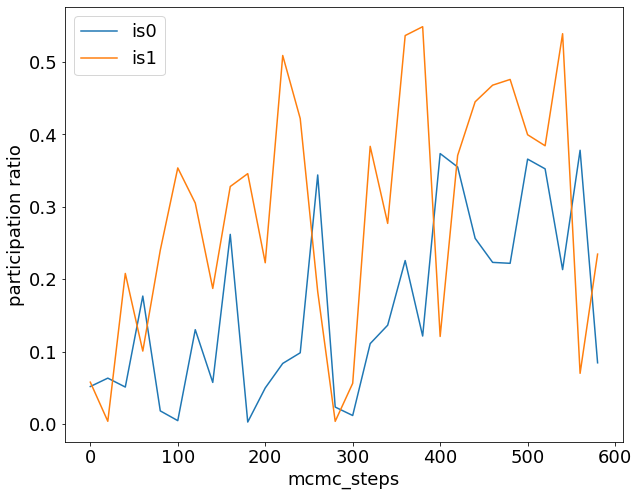

In [272]:
plt.figure(figsize=(10, 8))
plt.plot(range(0, 30*20, 20), torch.stack(part_ratios_is0).detach(), label="is0")
plt.plot(range(0, 30*20, 20), torch.stack(part_ratios_is1).detach(), label="is1")
plt.legend()
plt.xlabel("mcmc_steps")
plt.ylabel("participation ratio")

In [3]:
#TODO
# How participation ratio looks like with NO training!
# How participation ratio looks like with only MD training!

In [9]:
path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/3-test-flow-no-training"

#mh_is0_no_training = load_pickle_file("results_metropolis_is0_2552230/is0_mcmc_dic_2552230.pkl", path) 
#mh_is1_no_training = load_pickle_file("results_metropolis_is1_2552269/is1_mcmc_dic_2552269.pkl", path) 

mh_is0_no_training = load_pickle_file("results_metropolis_is0_2553700/is0_mcmc_dic_2553700.pkl", path) 
mh_is1_no_training = load_pickle_file("results_metropolis_is1_2553715/is1_mcmc_dic_2553715.pkl", path) 

In [10]:
accs_is0 = mh_is0_no_training["accs"].mean(dim=1)
accs_is1 = mh_is1_no_training["accs"].mean(dim=1)

Text(0, 0.5, 'Acceptance ratio')

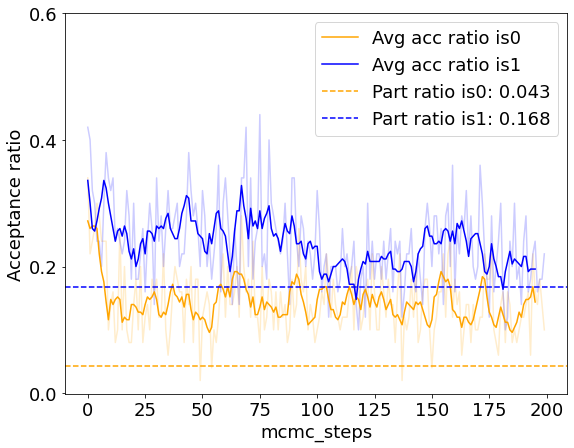

In [13]:
plt.figure(figsize=(9, 7))
plt.plot(accs_is0, c='orange', alpha=0.2)
plt.plot(accs_is1, c='blue', alpha=0.2)
plt.plot(avg_windows(accs_is0, 5, 1), c='orange', label='Avg acc ratio is0')
plt.plot(avg_windows(accs_is1, 5, 1), c='blue', label='Avg acc ratio is1')
plt.axhline(0.043, c='orange', linestyle="dashed", label='Part ratio is0: 0.043')
plt.axhline(0.168, c='blue', linestyle="dashed", label='Part ratio is1: 0.168')
plt.legend()
plt.yticks(np.linspace(0., 0.6, 4))
plt.xlabel("mcmc_steps")
plt.ylabel("Acceptance ratio")